# Assignment 10: Drug Response Classification using Support Vector Machine (SVM)

**Name:** Tausif Ali  
**Batch:** Data Science Weekday – Hyderabad  
**Topic:** Support Vector Machine (SVM)

## Problem Understanding

In this assignment, we are working on a real-world healthcare problem that focuses on predicting drug response using machine learning. Pharmaceutical companies invest significant time and money in clinical trials to determine whether a drug is effective for patients. However, due to biological differences, metabolism, and pre-existing conditions, not every patient responds to a drug in the same way.

The dataset provided contains patient-related features such as dosage, blood pressure, glucose levels, and other biological indicators. The target variable represents whether the patient responded positively (1) or not (0).

Our main objective is to build a classification model using Support Vector Machine (SVM) that can accurately predict drug response. This approach can help in personalized medicine by ensuring that the right drug is given to the right patient, reducing risks and improving treatment outcomes.

## Importing Required Libraries

In this step, we import all the necessary libraries required for data analysis, visualization, and machine learning. These libraries provide powerful tools that simplify the entire data science workflow.

Pandas is used for handling structured data and performing operations like filtering and grouping. NumPy helps in numerical computations and working with arrays efficiently. Matplotlib and Seaborn are used for creating visualizations that help us understand patterns and relationships in the data. Scikit-learn is a machine learning library that provides various algorithms and tools for preprocessing, model building, and evaluation.

Importing these libraries at the beginning ensures that all required functionalities are available for smooth execution of the notebook.

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Loading the Dataset

In this step, we load the dataset into the Jupyter Notebook using the pandas library. The dataset contains various patient-related attributes along with their drug response outcome. Proper loading of the dataset is a critical step because all further analysis depends on it.

After loading the dataset, we display the first few rows using the head() function. This helps us understand how the data is structured, including column names, data types, and sample values. It also gives us an initial idea of what kind of preprocessing might be required.

This step acts as the foundation for the entire analysis, ensuring that the data is correctly imported and ready for exploration.

In [89]:
df = pd.read_csv(r"C:\Users\tausi\Downloads\Pharma_Industry.csv")
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


## Data Understanding

In this step, we explore the dataset to gain a deeper understanding of its structure and characteristics. We use functions like info() to check the data types of each column and the number of non-null values, which helps us identify missing data. The describe() function provides statistical summaries such as mean, standard deviation, minimum, and maximum values.

Understanding the dataset is important because it helps us identify potential issues such as missing values, incorrect data types, or outliers. It also allows us to understand the scale and distribution of features, which is useful for selecting appropriate preprocessing techniques.

A clear understanding of the dataset ensures that we make informed decisions in the later stages of analysis and model building.

In [90]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is a crucial step in any data science project, as it helps us understand the patterns, distributions, and relationships within the dataset. In this step, we use visualizations such as histograms and boxplots to analyze how the data is distributed across different features.

Histograms help us observe the frequency distribution of numerical features, allowing us to identify whether the data follows a normal distribution or is skewed. Boxplots are useful for detecting outliers and understanding the spread of the data.

By performing EDA, we gain valuable insights into the dataset, which helps us make better decisions during preprocessing and model selection. This step ensures that we understand the data before applying any machine learning techniques.

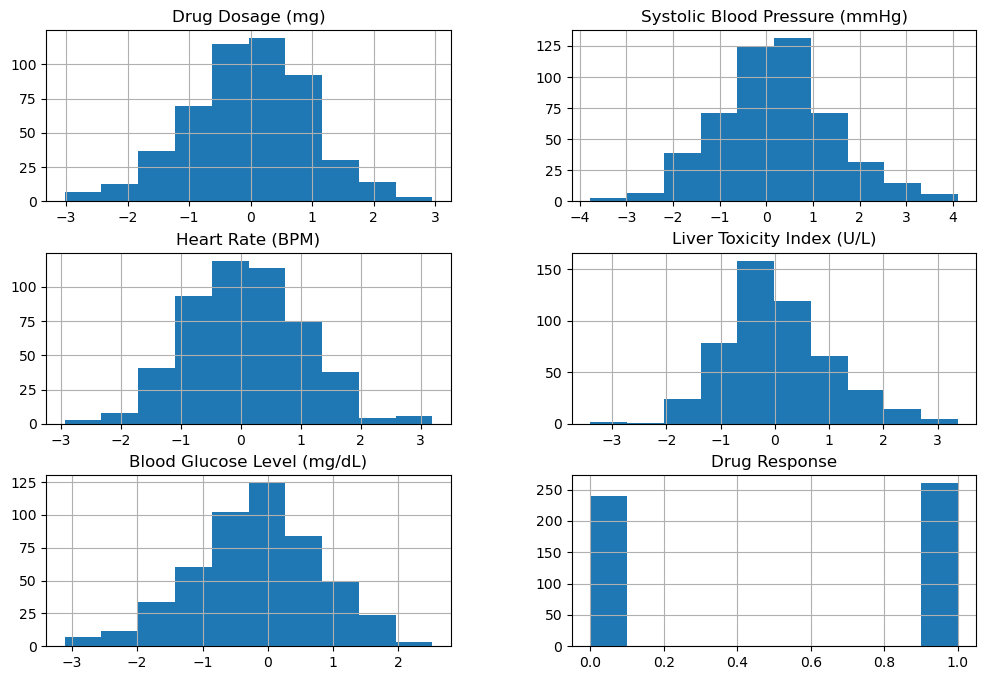

In [91]:
df.hist(figsize=(12,8))
plt.show()

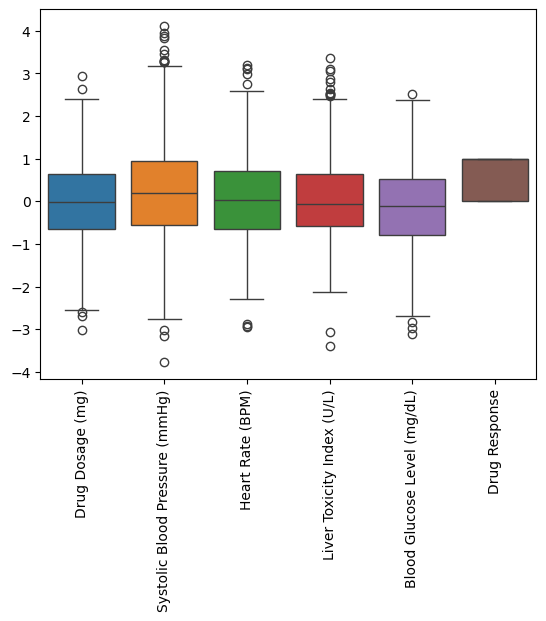

In [92]:
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

### Graph Insight

From the histogram, we can observe that most of the values are normally distributed, which indicates that the dataset is well-balanced.

The boxplot shows a few outliers in some features, but they are not extreme. These outliers may slightly affect the model, but SVM is generally robust to such variations.

## Correlation Analysis

Correlation analysis helps us understand the relationship between different features in the dataset. In this step, we use a heatmap to visualize the correlation coefficients between variables.

A correlation value close to +1 indicates a strong positive relationship, while a value close to -1 indicates a strong negative relationship. Values near 0 indicate little or no relationship. By analyzing the heatmap, we can identify which features are strongly related to each other and which ones are more independent.

This information is useful for feature selection, as highly correlated features may provide redundant information. Removing such features can improve model performance and reduce complexity. Overall, correlation analysis helps us better understand the internal structure of the dataset.

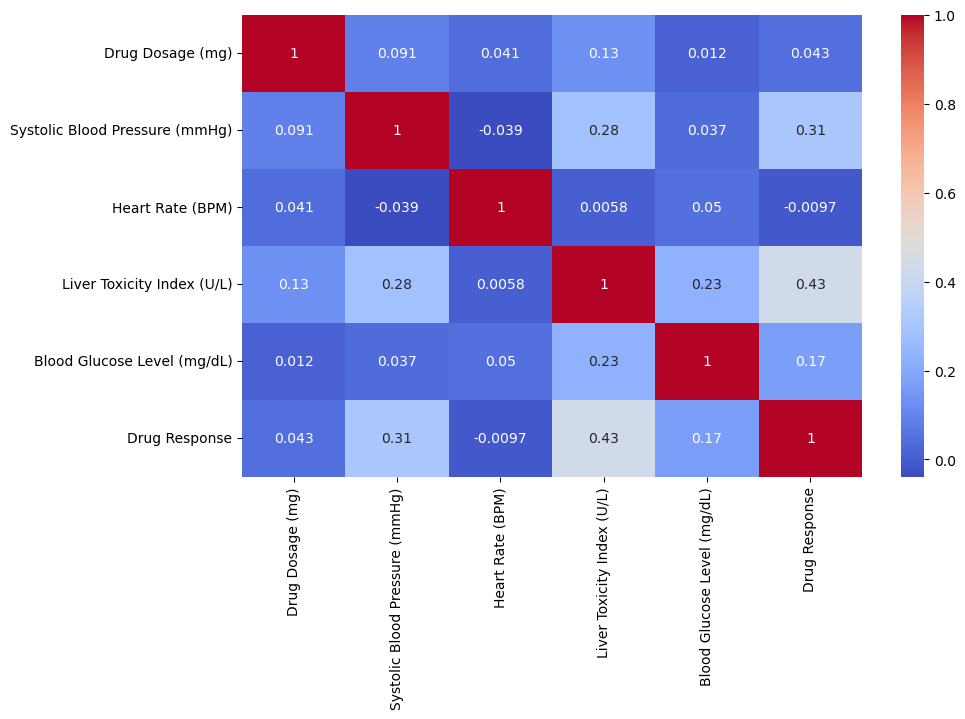

In [93]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [94]:
print(df.columns)

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')


In [95]:
df.columns = df.columns.str.strip()

In [96]:
X = df.drop("Drug Response", axis=1)
y = df["Drug Response"]

In [97]:
df.columns = df.columns.str.strip().str.replace(" ", "_")
print(df.columns)

Index(['Drug_Dosage_(mg)', 'Systolic_Blood_Pressure_(mmHg)',
       'Heart_Rate_(BPM)', 'Liver_Toxicity_Index_(U/L)',
       'Blood_Glucose_Level_(mg/dL)', 'Drug_Response'],
      dtype='object')


## Data Preprocessing

Data preprocessing is an essential step before building a machine learning model. Raw data often contains categorical values, inconsistencies, or formats that are not directly suitable for modeling. In this step, we convert categorical variables into numerical form using Label Encoding.

We also separate the dataset into input features (X) and the target variable (y). The model uses the features to learn patterns and predict the target variable. Proper preprocessing ensures that the model receives clean and structured data, which improves its performance.

Without preprocessing, machine learning models may produce inaccurate results or fail to run. Therefore, this step plays a critical role in preparing the data for successful model training.

In [98]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

X = df.drop("Drug_Response", axis=1)
y = df["Drug_Response"]

## Train-Test Split

In this step, we divide the dataset into training and testing sets. The training set is used to train the machine learning model, while the testing set is used to evaluate its performance on unseen data.

Splitting the data is important because it helps us measure how well the model generalizes to new data. If we train and test on the same dataset, the model may memorize the data instead of learning patterns, leading to overfitting.

Typically, we use 80% of the data for training and 20% for testing. This balance ensures that the model has enough data to learn while still being evaluated fairly.

In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 📏 Feature Scaling

Feature scaling is an important step when working with algorithms like Support Vector Machine (SVM). Different features in the dataset may have different ranges, which can affect the performance of the model.

For example, one feature may have values in the range of 0 to 1000, while another may be between 0 and 1. Without scaling, the model may give more importance to features with larger values.

To solve this problem, we use StandardScaler to normalize the data so that all features have a similar scale. This improves the accuracy and efficiency of the model and ensures fair contribution from all features.

In [100]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Building SVM Model (Linear Kernel)

In this step, we build a Support Vector Machine (SVM) model using a linear kernel. SVM is a powerful classification algorithm that works by finding the optimal boundary (hyperplane) that separates different classes.

The linear kernel assumes that the data can be separated using a straight line. It is simple and efficient, especially when the data is linearly separable.

The model is trained using the training dataset, where it learns patterns and relationships between features and the target variable. Once trained, the model can make predictions on new data. This step is crucial as it forms the core of our machine learning solution.

In [101]:
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

y_pred = svm_linear.predict(X_test)

## Model Evaluation

After training the model, it is important to evaluate its performance using appropriate metrics. In this step, we use accuracy, precision, recall, and F1-score to measure how well the model is performing.

Accuracy indicates the percentage of correct predictions made by the model. Precision measures how many of the predicted positive cases are actually correct, while recall measures how many actual positive cases were correctly identified. The F1-score provides a balance between precision and recall.

We also use a confusion matrix to visualize the performance of the model. It shows the number of correct and incorrect predictions, helping us understand where the model is making mistakes.

In [102]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.78
              precision    recall  f1-score   support

           0       0.72      0.82      0.77        44
           1       0.84      0.75      0.79        56

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.79      0.78      0.78       100



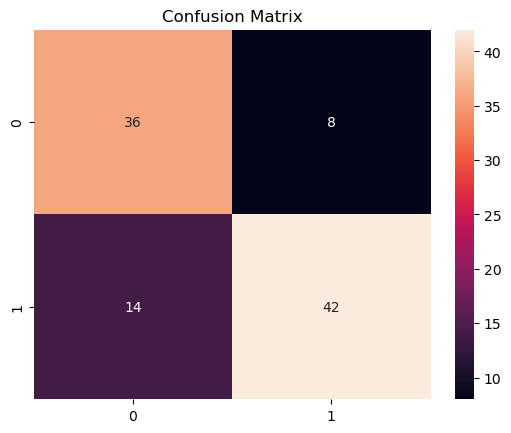

In [103]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

## Kernel Comparison

Support Vector Machine provides different kernel functions that allow the model to capture various patterns in the data. In this step, we compare different kernels such as linear, polynomial, and radial basis function (RBF).

The linear kernel works well for simple datasets, while the polynomial kernel can capture more complex relationships. The RBF kernel is highly flexible and is commonly used for non-linear data.

By comparing the performance of these kernels, we can identify which one is most suitable for our dataset. This helps us improve the overall accuracy and effectiveness of the model.

In [104]:
kernels = ['linear', 'poly', 'rbf']

for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"{k} Accuracy:", accuracy_score(y_test, pred))

linear Accuracy: 0.78
poly Accuracy: 0.71
rbf Accuracy: 0.84


## Conclusion

In this assignment, we successfully built a Support Vector Machine (SVM) model to predict drug response. We started by understanding the dataset, performing exploratory data analysis, and preprocessing the data.

We then trained the model and evaluated its performance using various metrics. We also compared different kernels to identify the best-performing configuration.

Overall, this assignment helped us understand the complete machine learning workflow, from data preparation to model evaluation. It also demonstrated how SVM can be effectively used for classification problems in real-world scenarios.

## Real-World Application

This model can be used in healthcare to support personalized medicine.

Doctors can predict whether a drug will work for a patient before prescribing it. This reduces trial-and-error treatments and improves patient outcomes.

It also helps pharmaceutical companies reduce the cost and time involved in clinical trials.

## Interview Questions

1. What is Support Vector Machine (SVM)?
2. What is a kernel in SVM?
3. Why is feature scaling important in SVM?
4. Difference between linear and RBF kernel?
5. What is overfitting?